In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

In [ ]:
import pandas as pd
import snowflake.connector
conn=snowflake.connector.connect(
    user='prakalya',
    password='xxxxxxxxxxxxxx',
    account='xxxxxxxxxxxxxxx',
    database='xxxxxx',
    schema='public',
    warehouse='COMPUTE_WH'
)
query='SELECT * from "water"';

In [ ]:
query='SELECT * FROM WATER'
d=pd.read_sql(query,conn)
conn.close()
print(d.head())

/tmp/ipykernel_6304/847324259.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d=pd.read_sql(query,conn)


         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [ ]:
d.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
d.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [ ]:

d.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
d.shape

(3276, 10)

In [ ]:
d.isnull().sum()


,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='median')
d[['PH']]=im.fit_transform(d[['PH']])
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='median')
d[['SULFATE']]=im.fit_transform(d[['SULFATE']])
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='median')
d[['TRIHALOMETHANES']]=im.fit_transform(d[['TRIHALOMETHANES']])

d.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


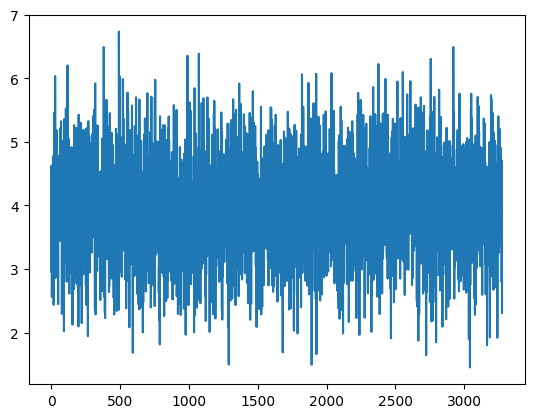

In [ ]:
#Data visualization
import matplotlib.pyplot as plt
b=d["TURBIDITY"]
plt.plot(b)

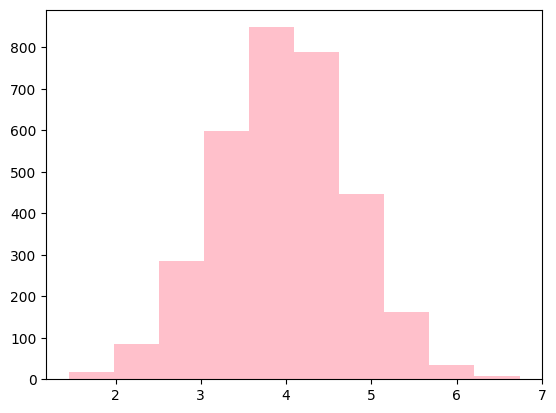

In [ ]:
plt.hist(b,color='pink')
plt.show()

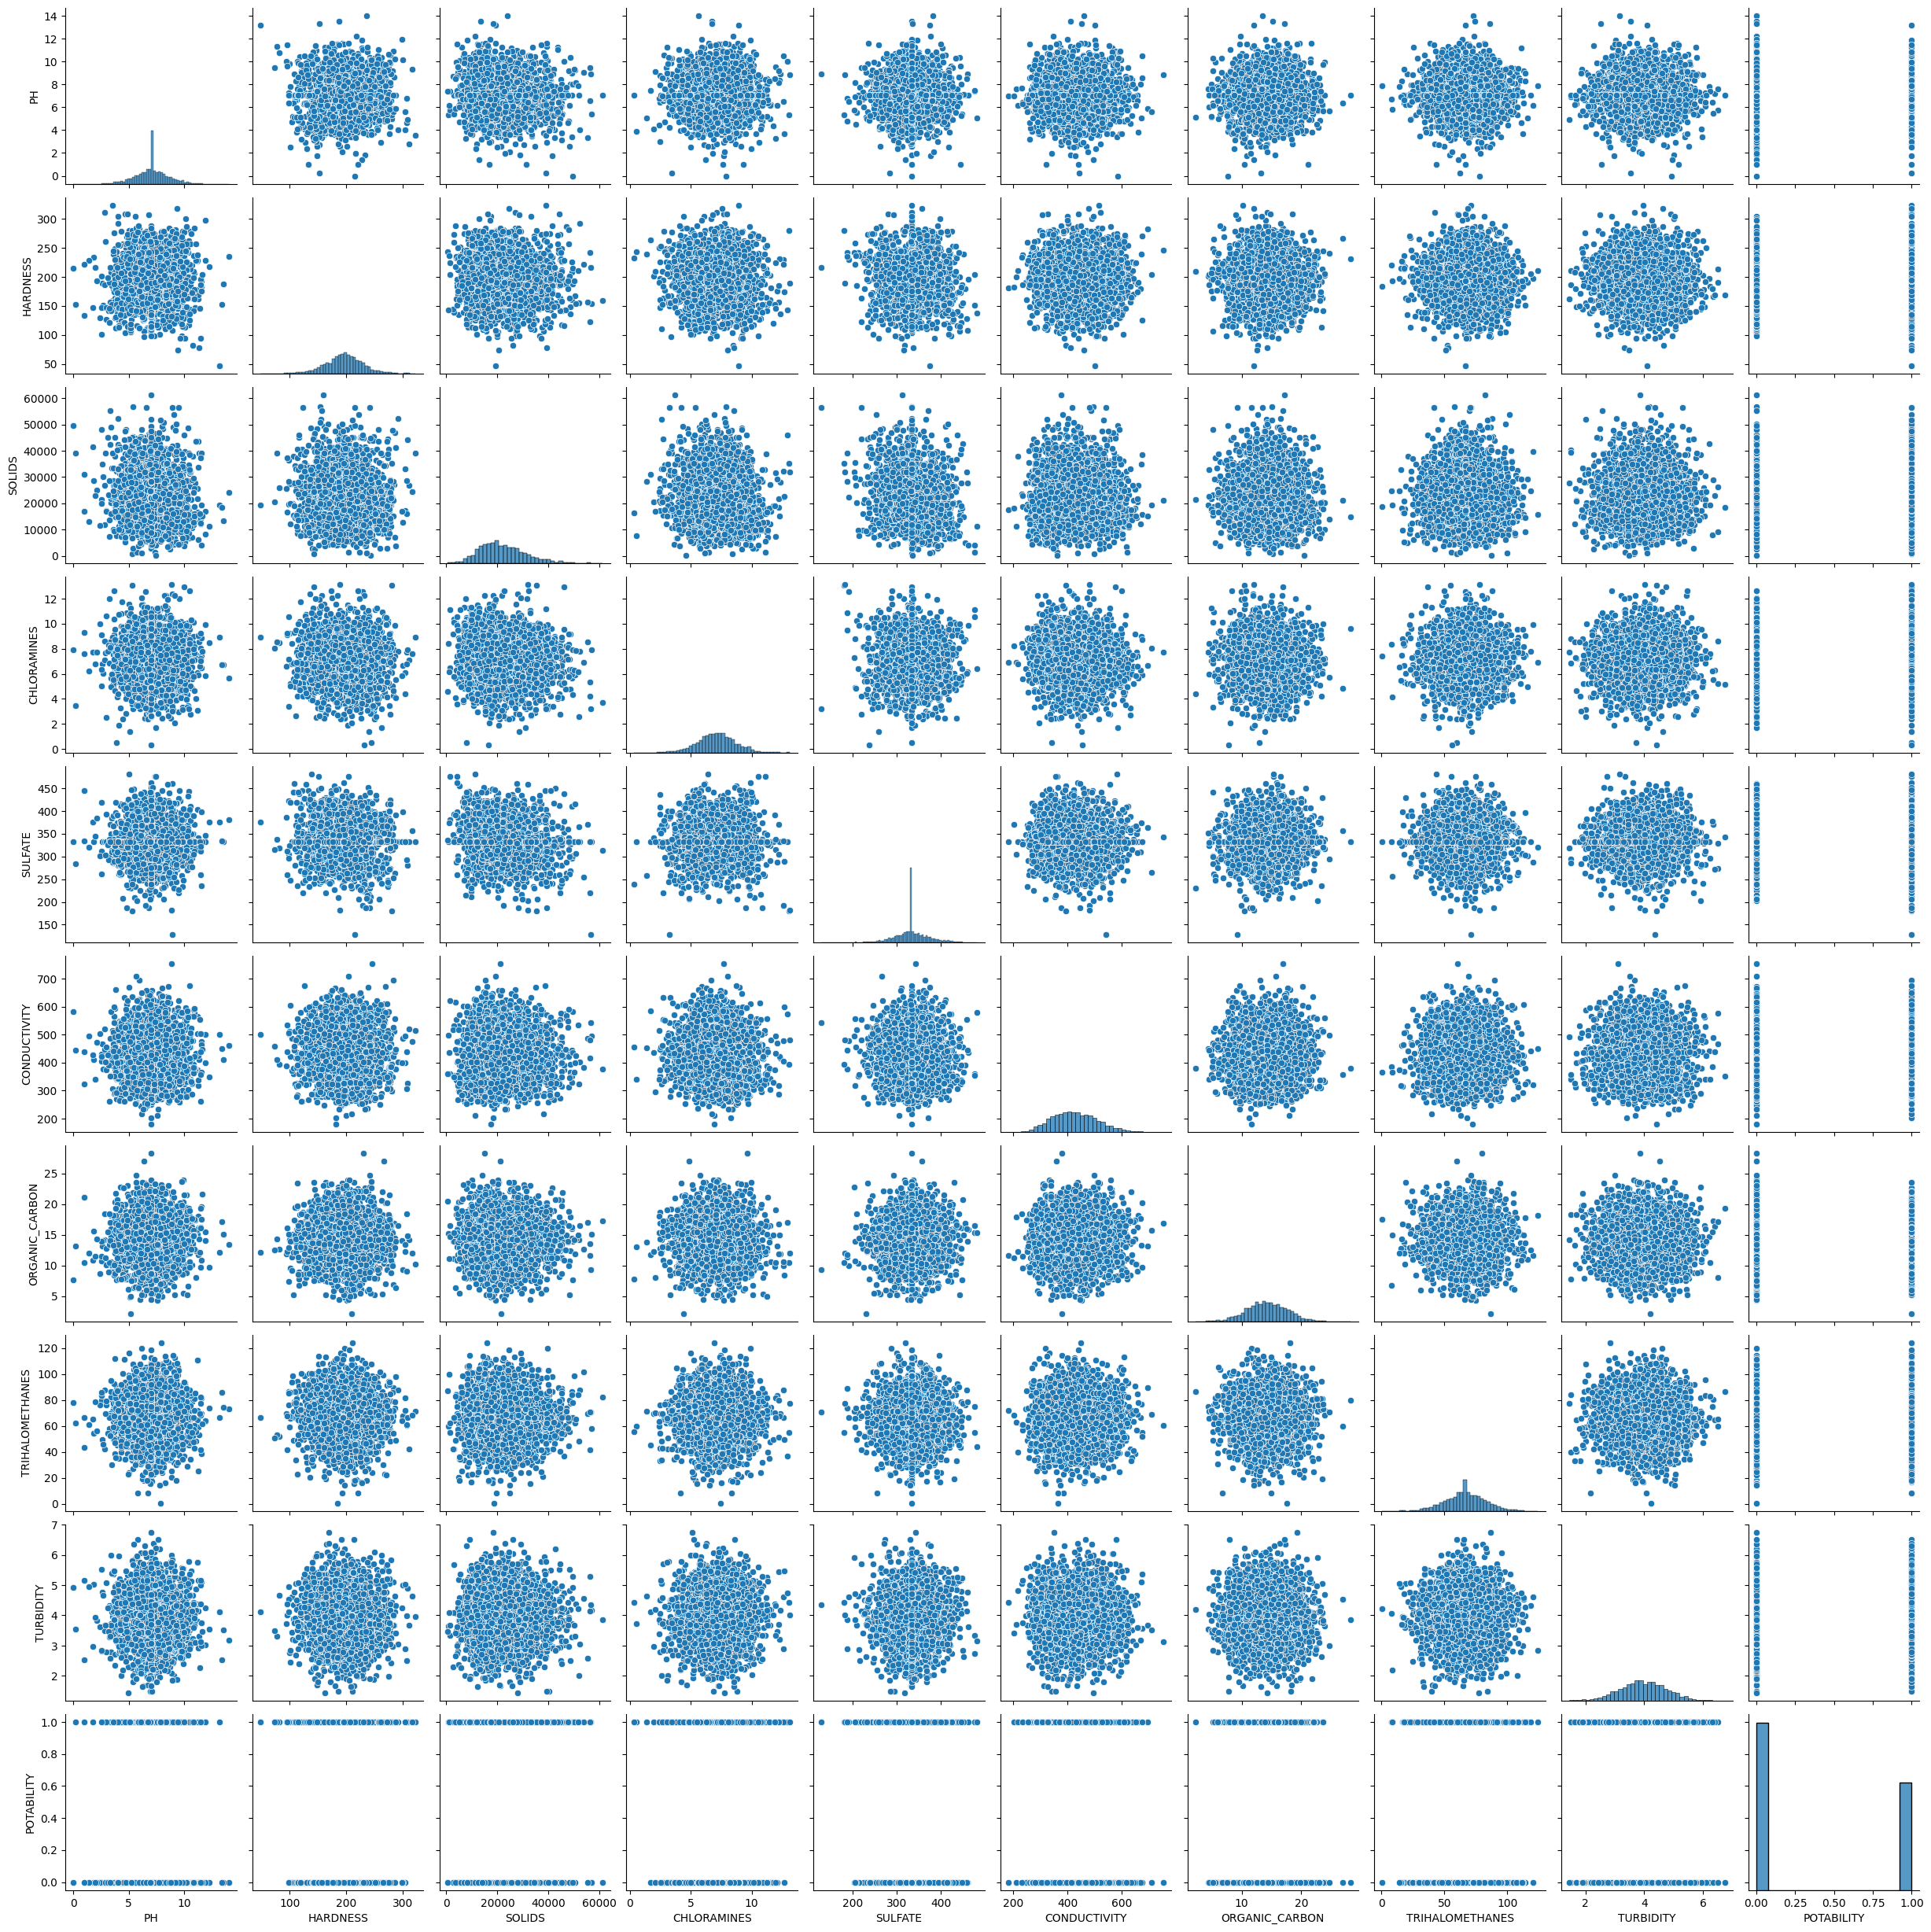

In [ ]:
import seaborn as sns
sns.pairplot(d)

In [ ]:
#Z_Score
from scipy.stats import zscore
import numpy as np
z_score=zscore(d)
d[np.abs(z_score)>4]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
253,6.800119,242.008082,39143.403329,9.501695,187.170714,376.456593,11.432466,73.777275,3.854940,1
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.622485,4.106924,1
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.622485,4.106924,1
275,5.324942,280.089655,35344.658047,13.043806,180.206746,392.421496,10.504820,55.084668,4.427138,1
285,3.882631,243.807950,7751.809491,0.530351,333.073546,341.291116,12.990592,60.109968,3.734001,1
351,8.848586,188.919983,32033.332019,13.127000,182.397370,479.791975,12.070444,77.671337,4.014682,1
365,4.788861,234.893703,28174.620516,10.850036,187.424131,444.854321,11.784799,89.010974,2.896852,1
726,0.227499,152.530111,39028.599340,3.462492,283.693782,443.029232,13.201943,62.322711,3.545741,1
810,0.989912,133.216942,16922.853899,9.293289,444.375731,322.291191,10.430076,43.578466,5.160604,1
1554,8.942046,215.673786,56488.672413,3.231438,129.000000,541.915468,9.313771,70.828374,4.354288,1


In [ ]:
#Standard scaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
scale= sc.fit_transform(d)
print(scale)

[[-2.54735465e-02  2.59194711e-01 -1.39470871e-01 ...  1.30543373e+00
  -1.28629758e+00 -7.99774743e-01]
 [-2.28471739e+00 -2.03641367e+00 -3.85986650e-01 ... -6.39186284e-01
   6.84217891e-01 -7.99774743e-01]
 [ 6.97319183e-01  8.47664833e-01 -2.40047337e-01 ...  8.00012586e-04
  -1.16736546e+00 -7.99774743e-01]
 ...
 [ 1.59565368e+00 -6.26829230e-01  1.27080989e+00 ...  2.18037800e-01
  -8.56006782e-01  1.25035206e+00]
 [-1.32494885e+00  1.04135450e+00 -1.14405809e+00 ...  7.02755628e-01
   9.50797383e-01  1.25035206e+00]
 [ 5.44611034e-01 -3.85462310e-02 -5.25811937e-01 ...  7.79510303e-01
  -2.12445866e+00  1.25035206e+00]]


In [ ]:
x=d.drop('POTABILITY',axis=1)
y = d[["POTABILITY"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#Fitting the dataset
from sklearn.svm import SVC
clf=SVC()
clf=clf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
#predicting
y_predict=clf.predict(x_test)

                       PH  HARDNESS    SOLIDS  CHLORAMINES   SULFATE  \
PH               1.000000  0.075760 -0.082004    -0.031741  0.014178   
HARDNESS         0.075760  1.000000 -0.046899    -0.030054 -0.092833   
SOLIDS          -0.082004 -0.046899  1.000000    -0.070148 -0.149747   
CHLORAMINES     -0.031741 -0.030054 -0.070148     1.000000  0.023762   
SULFATE          0.014178 -0.092833 -0.149747     0.023762  1.000000   
CONDUCTIVITY     0.017466 -0.023915  0.013831    -0.020486 -0.014182   
ORGANIC_CARBON   0.040240  0.003610  0.010242    -0.012653  0.027102   
TRIHALOMETHANES  0.003145 -0.012707 -0.008799     0.016614 -0.025657   
TURBIDITY       -0.036107 -0.014449  0.019546     0.002363 -0.009767   

                 CONDUCTIVITY  ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  
PH                   0.017466        0.040240         0.003145  -0.036107  
HARDNESS            -0.023915        0.003610        -0.012707  -0.014449  
SOLIDS               0.013831        0.010242      

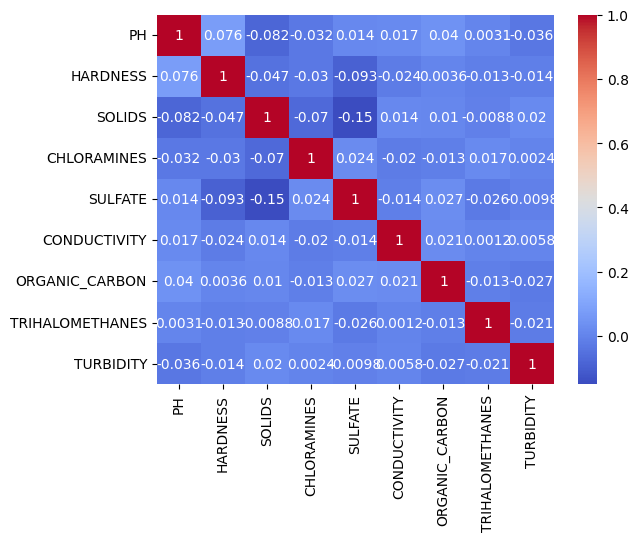

In [ ]:
#Heatmap
import seaborn as sns
correlation_matrix=x.corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.show()

In [ ]:
#Evaluatin metrics
from sklearn.metrics import accuracy_score
print("Accuracy score: ",accuracy_score(y_test,y_predict))

Accuracy score:  0.6280487804878049


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
print(cm)

[[412   0]
 [244   0]]


In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_predict)
print(cr)

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
